# Structure Functions and Inverse Structure Functions

Prove a relation between exponents in the structure functions of returns and its inverse (structure function of fhts)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from tqdm import tqdm, trange
from pathlib import Path
import sqlite3
from scipy import stats
from scipy.optimize import curve_fit

from stabilvol.utility.functions import query_binned_data, roll_windows, list_database_thresholds, stringify_threshold

MARKETS = [
    "UN", 
    "UW", 
    "LN", 
    "JT"
    ]
THRESHOLDS = ["3p0", "2p0"]

ROOT_DIR = Path().resolve().parent
DATABASE = ROOT_DIR / 'data/processed/trapezoidal_selection/stabilvol_logs.sqlite'
PRICES = ROOT_DIR / 'data/raw'
RETURNS = ROOT_DIR / 'data/interim'

## Prices Multifractality
The standard multifractal analysis in financial markets starts from stock prices

In [15]:
class InverseMultifractal:
    def __init__(self, price_series):
        # Convert prices to Log-Prices for scaling analysis
        # X(t) = ln(P(t))
        self.prices = np.array(price_series)
        self.log_prices = np.log(self.prices)
        self.n = len(self.log_prices)
        
    def get_standard_fluctuations(self, tau_lags, q_orders):
        """
        Standard Analysis: Fix Time (tau), Measure Volatility (dX)
        S_q(tau) ~ tau^zeta(q)
        """
        results = {}
        
        for q in q_orders:
            fluctuation_moments = []
            
            for tau in tau_lags:
                # Calculate differences for lag tau
                # dX = |X(t+tau) - X(t)|
                dX = np.abs(self.log_prices[tau:] - self.log_prices[:-tau])
                
                # Calculate q-th moment
                moment = np.nanmean(dX ** q)
                fluctuation_moments.append(moment)
            
            # Fit Log-Log to find zeta(q)
            # log(moment) = zeta * log(tau) + C
            slope, intercept, _, _, _ = stats.linregress(np.log(tau_lags), np.log(fluctuation_moments))
            results[q] = slope
            
        return results

    def get_inverse_exit_times(self, thresholds, q_orders):
        """
        Inverse Analysis: Fix Threshold (delta), Measure Time (tau)
        I_q(delta) ~ delta^chi(q)
        """
        results = {}
        
        # Pre-calculate exit times for each threshold
        # This is the computationally heavy part
        avg_exit_moments = {q: [] for q in q_orders}
        
        for delta in thresholds:
            exit_times = []
            t = 0
            while t < self.n - 1:
                # Current price reference
                ref_price = self.log_prices[t]
                if np.isnan(ref_price):
                    t += 1
                    continue
                
                # Find the first future point where price exits [ref-delta, ref+delta]
                # Efficient search using numpy where
                future_prices = self.log_prices[t+1:]
                
                dist = np.abs(future_prices - ref_price)
                
                # Create mask, treating NaNs as False (not a crossing)
                crossings = np.greater_equal(dist, delta, where=~np.isnan(dist))
                
                if np.any(crossings):
                    # Get the index of the first True value
                    # +1 because index 0 in future_prices is t+1
                    tau = np.argmax(crossings) + 1 
                    exit_times.append(tau)
                    
                    # Move t forward. 
                    # OPTION A: Non-overlapping (jump to exit). 
                    # OPTION B: Overlapping (t += 1). 
                    # We use Option A for distinct event analysis.
                    t += tau 
                else:
                    break # End of series reached without exit
            
            if len(exit_times) < 10:
                print(f"Warning: Not enough events for threshold {delta}")
                for q in q_orders:
                    avg_exit_moments[q].append(np.nan)
                continue

            # Calculate moments of exit times
            for q in q_orders:
                moment = np.mean(np.array(exit_times) ** q)
                avg_exit_moments[q].append(moment)

        # Fit Log-Log to find chi(q)
        # log(time_moment) = chi * log(delta) + C
        for q in q_orders:
            # Filter out NaNs
            valid_idx = np.isfinite(avg_exit_moments[q])
            if np.sum(valid_idx) > 2:
                y = np.log(np.array(avg_exit_moments[q])[valid_idx])
                x = np.log(np.array(thresholds)[valid_idx])
                slope, _, _, _, _ = stats.linregress(x, y)
                results[q] = slope
            else:
                results[q] = np.nan
                
        return results


In [19]:
# q-orders to test (e.g., 1st moment, 2nd moment)
qs = [1, 2, 3] 

taus = np.arange(1, 31).astype(int)

# Thresholds for Inverse Analysis (e.g., 0.5% to 5% moves)
# Note: These should be in Log-Scale units (approx percentage)
deltas = np.logspace(np.log10(0.0001), np.log10(0.1), 50)
results = {}
for market in MARKETS:
    df = pd.read_pickle(PRICES / f"{market}.pickle")
    market_results = []
    for ticker, prices in tqdm(df.iloc[:, :5].items()):
        # Initialize Analyzer
        analyzer = InverseMultifractal(prices)

        zeta_exponents = analyzer.get_standard_fluctuations(taus, qs)
        chi_exponents = analyzer.get_inverse_exit_times(deltas, qs)
        market_results.append([zeta_exponents[q] * chi_exponents[q] for q in qs])
    
    results[market] = np.mean(np.array(market_results), axis=0)
    
results = pd.DataFrame().from_dict(results, orient="index", columns=[f"q{q}" for q in qs])

0it [00:00, ?it/s]

5it [00:21,  4.33s/it]
5it [00:22,  4.57s/it]
5it [00:14,  2.98s/it]
5it [00:24,  4.98s/it]


## Multifractality of Returns
Here we already computer our two-thresholds fht, and we need to load them from the database.
Also, we need the structure function of (log) returns.

In [4]:
def setup_optimized_connection(database_path):
    """Setup an optimized SQLite connection"""
    conn = sqlite3.connect(database_path)
    # SQLite optimizations
    conn.execute("PRAGMA journal_mode=WAL")
    conn.execute("PRAGMA synchronous=NORMAL") 
    conn.execute("PRAGMA cache_size=100000")  # Increase cache
    conn.execute("PRAGMA temp_store=MEMORY")
    return conn


df_experiments = list_database_thresholds(DATABASE)

START = 0.3
df_experiments[df_experiments["Start"] == START]
thresholds = list(sorted({(START, end) for end in df_experiments[df_experiments["Start"] == START]["End"] if end < START}))

# Connect to the SQLite database
conn = setup_optimized_connection(DATABASE)

thresholds

Start Threshold 	     End Thresholds      
       -0.5     	 -0.49  -0.48  -0.47  -0.46  -0.45  -0.44  -0.43  -0.42  -0.41   -0.4  -0.39  -0.38  -0.37  -0.36  -0.35  -0.34  -0.33  -0.32  -0.31   -0.3 
       -0.4     	 -0.39  -0.38  -0.37  -0.36  -0.35  -0.34  -0.33  -0.32  -0.31   -0.3  -0.29  -0.28  -0.27  -0.26  -0.25  -0.24  -0.23  -0.22  -0.21   -0.2 
       -0.3     	 -0.29  -0.28  -0.27  -0.26  -0.25  -0.24  -0.23  -0.22  -0.21   -0.2  -0.19  -0.18  -0.17  -0.16  -0.15  -0.14  -0.13  -0.12  -0.11   -0.1 
      -0.25     	 -0.24  -0.23  -0.22  -0.21   -0.2  -0.19  -0.18  -0.17  -0.16  -0.15  -0.14  -0.13  -0.12  -0.11   -0.1  -0.09  -0.08  -0.07  -0.06  -0.05 
       -0.2     	 -0.19  -0.18  -0.17  -0.16  -0.15  -0.14  -0.13  -0.12  -0.11   -0.1  -0.09  -0.08  -0.07  -0.06  -0.05  -0.04  -0.03  -0.02  -0.01    0.0 
      -0.15     	 -0.14  -0.13  -0.12  -0.11   -0.1  -0.09  -0.08  -0.07  -0.06  -0.05  -0.04  -0.03  -0.02  -0.01   -0.0   0.01   0.02   0.03   0.04   0.05 
       -0

[(0.3, 0.1),
 (0.3, 0.11),
 (0.3, 0.12),
 (0.3, 0.13),
 (0.3, 0.14),
 (0.3, 0.15),
 (0.3, 0.16),
 (0.3, 0.17),
 (0.3, 0.18),
 (0.3, 0.19),
 (0.3, 0.2),
 (0.3, 0.21),
 (0.3, 0.22),
 (0.3, 0.23),
 (0.3, 0.24),
 (0.3, 0.25),
 (0.3, 0.26),
 (0.3, 0.27),
 (0.3, 0.28),
 (0.3, 0.29)]

In [7]:
class InverseMultifractal2:
    def __init__(self, returns_series):
        self.returns = np.array(returns_series)
        self.n = len(self.returns)
        
    def get_standard_fluctuations(self, tau_lags, q_orders):
        """
        Standard Analysis: Fix Time (tau), Measure Volatility (dX)
        S_q(tau) ~ tau^zeta(q)
        """
        results = {}
        
        for q in q_orders:
            fluctuation_moments = []
            
            for tau in tau_lags:
                # Calculate differences for lag tau
                # dX = |X(t+tau) - X(t)|
                dX = np.abs(self.returns[tau:] - self.returns[:-tau])
                
                # Calculate q-th moment
                moment = np.nanmean(dX ** q)
                fluctuation_moments.append(moment)
            
            # Fit Log-Log to find zeta(q)
            # log(moment) = zeta * log(tau) + C
            slope, intercept, _, _, _ = stats.linregress(np.log(tau_lags), np.log(fluctuation_moments))
            results[q] = slope
            
        return results

    def get_inverse_exit_times(self, market, thresholds, q_orders):
        """
        Inverse Analysis: Fix Threshold (delta), Measure Time (tau)
        I_q(delta) ~ delta^chi(q)
        """
        results = {}
        
        # Pre-calculate exit times for each threshold
        # This is the computationally heavy part
        avg_exit_moments = {q: [] for q in q_orders}
        for ts in thresholds:
            fhts = query_binned_data(
                market, "1980-01-01", "2022-31-12",
                t1_string=stringify_threshold(ts[0]), t2_string=stringify_threshold(ts[1]),
                min_bins=-1,
                conn=conn
            )[0]["FHT"].values

            # Calculate moments of exit times
            for q in q_orders:
                moment = np.mean(np.array(fhts) ** q)
                avg_exit_moments[q].append(moment)

        # Fit Log-Log to find chi(q)
        # log(time_moment) = chi * log(delta) + C
        for q in q_orders:
            # Filter out NaNs
            valid_idx = np.isfinite(avg_exit_moments[q])
            if np.sum(valid_idx) > 2:
                y = np.log(np.array(avg_exit_moments[q])[valid_idx])
                x = np.log(np.array(thresholds)[valid_idx, 1])
                slope, _, _, _, _ = stats.linregress(x, y)
                results[q] = slope
            else:
                results[q] = np.nan
                
        return results


In [20]:
qs = [1, 2, 3]

taus = np.arange(1, 31).astype(int)

results = {}
df = pd.read_pickle(RETURNS / f"UN_log.pickle")
returns = df.iloc[:, 10]
# Initialize Analyzer
analyzer = InverseMultifractal2(returns)

zeta_exponents = analyzer.get_standard_fluctuations(taus, qs)
chi_exponents = analyzer.get_inverse_exit_times("UN", thresholds, qs)

# The Comparison Output
print(f"{'q':<5} | {'Zeta (Std)':<12} | {'Chi (Inv)':<12} | {'Product (Z*C)':<12}")
print("-" * 50)
for q in qs:
    z = zeta_exponents[q]
    c = chi_exponents[q]
    prod = z * c
    print(f"{q:<5} | {z:<12.4f} | {c:<12.4f} | {prod:<12.4f}")

q     | Zeta (Std)   | Chi (Inv)    | Product (Z*C)
--------------------------------------------------
1     | 0.0007       | 0.1668       | 0.0001      
2     | -0.0153      | 0.2833       | -0.0043     
3     | -0.0536      | 0.3569       | -0.0191     


In [29]:
qs = [1, 2, 3]

taus = np.arange(1, 31).astype(int)

results = {}
for market in MARKETS:
    df = pd.read_pickle(RETURNS / f"{market}_log.pickle")
    market_results = []
    for ticker, prices in tqdm(df.iloc[:, :100].items()):
        # Initialize Analyzer
        analyzer = InverseMultifractal2(prices)

        zeta_exponents = analyzer.get_standard_fluctuations(taus, qs)
        chi_exponents = analyzer.get_inverse_exit_times(market, thresholds, qs)
        market_results.append([zeta_exponents[q] * chi_exponents[q] for q in qs])
    
    results[market] = np.mean(np.array(market_results), axis=0)

results = pd.DataFrame().from_dict(results, orient="index", columns=[f"q{q}" for q in qs])
results

100it [00:11,  8.58it/s]
100it [00:13,  7.16it/s]
100it [00:17,  5.77it/s]
100it [00:22,  4.49it/s]


,q1,q2,q3
UN,0.000299,-0.002914,-0.016815
UW,-0.000256,-0.003691,-0.012839
LN,0.000460,-0.001036,-0.008557
JT,-0.000454,0.001405,0.007421


## Standard FHT with one barrier
This time we **do not** take the log of the series (they are already log returns)

In [27]:
class InverseMultifractal3:
    def __init__(self, price_series):
        self.prices = np.array(price_series)
        self.n = len(self.prices)
        
    def get_standard_fluctuations(self, tau_lags, q_orders):
        """
        Standard Analysis: Fix Time (tau), Measure Volatility (dX)
        S_q(tau) ~ tau^zeta(q)
        """
        results = {}
        
        for q in q_orders:
            fluctuation_moments = []
            
            for tau in tau_lags:
                # Calculate differences for lag tau
                # dX = |X(t+tau) - X(t)|
                dX = np.abs(self.prices[tau:] - self.prices[:-tau])
                
                # Calculate q-th moment
                moment = np.nanmean(dX ** q)
                fluctuation_moments.append(moment)
            
            # Fit Log-Log to find zeta(q)
            # log(moment) = zeta * log(tau) + C
            slope, intercept, _, _, _ = stats.linregress(np.log(tau_lags), np.log(fluctuation_moments))
            results[q] = slope
            
        return results

    def get_inverse_exit_times(self, thresholds, q_orders):
        """
        Inverse Analysis: Fix Threshold (delta), Measure Time (tau)
        I_q(delta) ~ delta^chi(q)
        """
        results = {}
        
        # Pre-calculate exit times for each threshold
        # This is the computationally heavy part
        avg_exit_moments = {q: [] for q in q_orders}
        
        for delta in thresholds:
            exit_times = []
            t = 0
            while t < self.n - 1:
                # Current price reference
                ref_price = self.prices[t]
                if np.isnan(ref_price):
                    t += 1
                    continue
                
                # Find the first future point where price exits [ref-delta, ref+delta]
                # Efficient search using numpy where
                future_prices = self.prices[t+1:]
                
                dist = np.abs(future_prices - ref_price)
                
                # Create mask, treating NaNs as False (not a crossing)
                crossings = np.greater_equal(dist, delta, where=~np.isnan(dist))
                
                if np.any(crossings):
                    # Get the index of the first True value
                    # +1 because index 0 in future_prices is t+1
                    tau = np.argmax(crossings) + 1 
                    exit_times.append(tau)
                    
                    # Move t forward. 
                    # OPTION A: Non-overlapping (jump to exit). 
                    # OPTION B: Overlapping (t += 1). 
                    # We use Option A for distinct event analysis.
                    t += tau 
                else:
                    break # End of series reached without exit
            
            if len(exit_times) < 10:
                print(f"Warning: Not enough events for threshold {delta}")
                for q in q_orders:
                    avg_exit_moments[q].append(np.nan)
                continue

            # Calculate moments of exit times
            for q in q_orders:
                moment = np.mean(np.array(exit_times) ** q)
                avg_exit_moments[q].append(moment)

        # Fit Log-Log to find chi(q)
        # log(time_moment) = chi * log(delta) + C
        for q in q_orders:
            # Filter out NaNs
            valid_idx = np.isfinite(avg_exit_moments[q])
            if np.sum(valid_idx) > 2:
                y = np.log(np.array(avg_exit_moments[q])[valid_idx])
                x = np.log(np.array(thresholds)[valid_idx])
                slope, _, _, _, _ = stats.linregress(x, y)
                results[q] = slope
            else:
                results[q] = np.nan
                
        return results


In [30]:
qs = [1, 2, 3]

taus = np.arange(1, 31).astype(int)
deltas = np.array(thresholds)[:, 1] 

results_classic = {}
for market in MARKETS:
    df = pd.read_pickle(RETURNS / f"{market}_log.pickle")
    market_results = []
    for ticker, returns in tqdm(df.iloc[:, :10].items()):
        # Initialize Analyzer
        analyzer = InverseMultifractal3(returns)

        zeta_exponents = analyzer.get_standard_fluctuations(taus, qs)
        chi_exponents = analyzer.get_inverse_exit_times(deltas, qs)
        market_results.append([zeta_exponents[q] * chi_exponents[q] for q in qs])
    
    results_classic[market] = np.mean(np.array(market_results), axis=0)

results_classic = pd.DataFrame().from_dict(results_classic, orient="index", columns=[f"q{q}" for q in qs])
results_classic

1it [00:00,  7.97it/s]

10it [00:01,  9.21it/s]
10it [00:01,  8.04it/s]
10it [00:00, 12.05it/s]
10it [00:01,  6.71it/s]


,q1,q2,q3
UN,0.000388,-0.001572,-0.008636
UW,0.000613,-0.004476,-0.016357
LN,0.000742,-0.001381,-0.014459
JT,0.000516,-0.001255,-0.007742


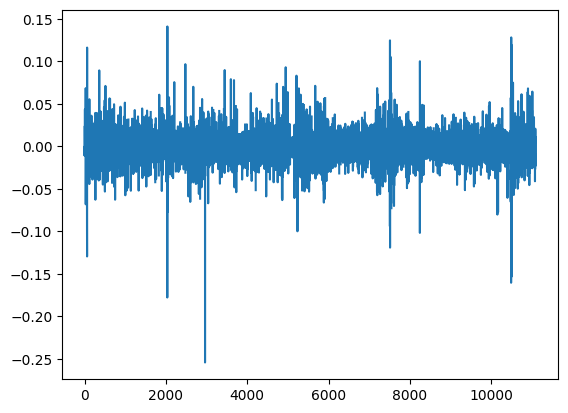

In [24]:
plt.plot(returns["UN"].iloc[:, 1].values)